# IMPORT PACKAGES

In [91]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE

# SELECT HEALTHY

In [92]:
# metadata=pd.read_excel('HNG.xlsx',sheet_name='QC V1')
# metadata

In [93]:
# Cancer=metadata[metadata['Type']=='Gastric']
# Cancer

In [94]:
# Healthy=metadata[metadata['Type']=='Healthy']
# Healthy

In [95]:
# # def Select_healthy(Cancer,Healthy,n=2,col_cohort='SMBM5_Cohort'): 
# n=2
# col_cohort='Cohort'
# for i in range(n):  
#         for s in list(Cancer['SampleID']):
#                 df=Cancer[Cancer['SampleID']==s]
#                 age=list(df['Age'])[0]
#                 gender=list(df['Gender'])[0]
#                 # run=list(df['R'])[0]
#                 cohort=list(df[col_cohort])[0]

#                 dfh=Healthy[(Healthy['Gender']==gender)&(Healthy[col_cohort]!='Discovery')&(Healthy[col_cohort]!='Unseen')]#&(Healthy['Rerun']=='No')
#                 dfh['gap_age']=dfh.apply(lambda r: abs(r['Age']-age),axis=1)
#                 # dfh['gap_run']=dfh.apply(lambda r: abs(r['R']-run),axis=1)
#                 # dfh1=dfh[dfh['gap_age']<=5]
#                 gap_age1=[]
#                 for gap in list(dfh['gap_age']):
#                         if gap <= 3:
#                                 gap_age1+=[0]
#                         elif gap <= 6:
#                                 gap_age1 +=[1]
#                         elif gap <= 10:
#                                 gap_age1 +=[2]
#                         else:
#                                 gap_age1+=[3]
#                 dfh['gap_age1']=gap_age1
#                 # dfh.sort_values(by=['gap_age1','gap_run','gap_age'],inplace=True)
#                 dfh.sort_values(by=['gap_age1','gap_age'],inplace=True)
#                 ind=dfh.index[0]
#                 Healthy.loc[ind,col_cohort]=cohort
#                 Healthy.loc[ind,'Pair']=s
# Healthy

In [96]:
# Healthy=Healthy[Healthy['Cohort']=='Discovery']
# Healthy

In [97]:
# Healthy.to_clipboard(index=False)

# DEFINE FUNCTION ENTROPY

In [98]:
def histogram_entropy(data, bins=500):
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True)

    # Normalize histogram to represent a probability density function
    hist = hist / hist.sum()
    
    # Remove zero entries to avoid log(0)
    hist = hist[hist > 0]
    
    # Calculate entropy
    entropy = -np.sum(hist * np.log(hist))
    
    return entropy

# DEFINE FUNCTION

In [99]:
#Hàm wilcoxon mới
def STATS_binary(df_1,df_2,col_start,name_1,name_2,groups_PADJ=[]):
    # import pandas as pd
    # import numpy as np
    # from statsmodels.stats.multitest import fdrcorrection
    # from scipy import stats
    # import math
    Mean_1,Mean_2,Median_1,Median_2,Feature,P_value,AUC,Log2FC, Log2FC_Median=[],[],[],[],[],[],[],[],[]
    SD_1,SD_2,CVpct_1,CVpct_2=[],[],[],[]
    Entropy_1,Entropy_2=[],[]
    for i in range(col_start,df_1.shape[1]):
        #Mean
        m1=np.mean(list(df_1.iloc[:,i]))
        m2=np.mean(list(df_2.iloc[:,i]))
        Mean_1+=[m1]
        Mean_2+=[m2]
        #Median
        me1=np.median(list(df_1.iloc[:,i]))
        me2=np.median(list(df_2.iloc[:,i]))
        Median_1+=[me1]
        Median_2+=[me2]
        #P-value
        P_value+=[stats.ranksums(df_1.iloc[:,i],df_2.iloc[:,i])[1]]
        #Log2FC
        if m1 !=0 and m2 !=0:
            Log2FC+=[math.log2(abs(m2/m1))]
        else:
            Log2FC+=[0]

        if me1 !=0 and me2 !=0:
            Log2FC_Median+=[math.log2(abs(me2/me1))]
        else:
            Log2FC_Median+=[0]
        #Features
        Feature+=[df_1.columns[i]]
        #AUC
        AUC+=[metrics.roc_auc_score([0]*len(df_1)+[1]*len(df_2), list(df_1.iloc[:,i])+list(df_2.iloc[:,i]))]
        #SD and CV%
        sd1=np.std(list(df_1.iloc[:,i]))
        sd2=np.std(list(df_2.iloc[:,i]))
        SD_1+=[sd1]
        SD_2+=[sd2]
        if m1 != 0:
            CVpct_1+=[sd1/m1*100]
        else: 
            CVpct_1+=[np.NaN]
        if m2 != 0:
            CVpct_2+=[sd2/m2*100]
        else: 
            CVpct_2+=[np.NaN]
        #Entropy
        Entropy_1+=[histogram_entropy(data=list(df_1.iloc[:,i]),bins=int(len(df_1)/2))]
        Entropy_2+=[histogram_entropy(data=list(df_2.iloc[:,i]),bins=int(len(df_2)/2))]
    else:
        result=pd.DataFrame({'FEATURES':Feature,
                             'Mean of '+name_1:Mean_1,
                             'Mean of '+name_2:Mean_2,
                             'Median of '+name_1:Median_1,
                             'Median of '+name_2:Median_2,
                             'SD of '+name_1:SD_1,
                             'SD of '+name_2:SD_2,
                             'CV% of '+name_1:CVpct_1,
                             'CV% of '+name_2:CVpct_2,
                             'Entropy of '+name_1:Entropy_1,
                             'Entropy of '+name_2:Entropy_2, 
                             'Log2FC of '+name_1+' vs '+name_2:Log2FC,
                             'Log2FC Median of '+name_1+' vs '+name_2:Log2FC_Median,
                             'P of '+name_1+' vs '+name_2:P_value})
        #Adjust p-value
        PADJ=[]
        for g in groups_PADJ:
            filtered_result=result[result['FEATURES'].str.startswith(g)]
            if len(filtered_result)>0:
                PADJ+=list(fdrcorrection(filtered_result['P of '+name_1+' vs '+name_2])[1])
            else:
                PADJ+=[] 
        result['PADJ of '+name_1+' vs '+name_2]=PADJ
        result['Round_Mean of '+name_1]=result.apply(lambda row: round(row['Mean of '+name_1],2),axis=1)
        result['Round_Mean of '+name_2]=result.apply(lambda row: round(row['Mean of '+name_2],2),axis=1)
        result['-log10(p-value) of '+name_1+' vs '+name_2]=result.apply(lambda row: -math.log10(row['PADJ of '+name_1+' vs '+name_2]),axis=1)
        result['Distance of '+name_1+' vs '+name_2]=result.apply(lambda row: row['Mean of '+name_2]-row['Mean of '+name_1],axis=1)
        result['AUC of '+name_1+' vs '+name_2]=AUC
        result['AUCADJ of '+name_1+' vs '+name_2]=result.apply(lambda row: row['AUC of '+name_1+' vs '+name_2] if row['Log2FC of '+name_1+' vs '+name_2]>=0 else 1-row['AUC of '+name_1+' vs '+name_2],axis=1)
    return result
def STATS_features(df,pair,groups_PADJ=[],col_start=5):
    # import pandas as pd

    Gastric=df[df['Type']=='Gastric']
    Healthy=df[df['Type']=='Healthy']

    Group={'Gastric':Gastric,
           'Healthy':Healthy
           }
    result=pd.DataFrame()
    for p in pair:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]
        stats_bi=STATS_binary(df_1=Group[name_1],df_2=Group[name_2],col_start=col_start,name_1=name_1,name_2=name_2,groups_PADJ=groups_PADJ)
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
    return result

def introundup(a):
    import math
    b=math.ceil(a)
    c=len(str(b))
    d=pow(10,c-1)
    e=a/d
    f=math.ceil(e)
    g=f*d
    return g
def features_include(features,lst_fea,fsm,f_group):
    df=pd.DataFrame({'FEATURES':list(lst_fea)})
    Number=[]
    for f in features:
        Number+=[len(df[df['FEATURES'].str.startswith(f)])]
    fea_include=pd.DataFrame({'FEATURES':features,fsm+' | '+f_group:Number})
    return fea_include

## Heatmapfea

In [100]:
#Heatmap các features
def heatmapfea(f='TMD'):
# TMD
# GWMD
# CNA
# flen
# MOTIF_END
# GWFP_long
# GWFP_short
# GWFP_total
# GWFP_ratio
    
    custom_lines = [
                    Line2D([0], [0], color='b', lw=4),
                    # Line2D([0], [0], color='g', lw=4),
                    # Line2D([0], [0], color='goldenrod', lw=4),
                    Line2D([0], [0], color='r', lw=4),
                    ]
    regex='Class|'+f
    data_f = fea[f].filter(regex=(regex)).sort_values(by='Class')
    # dict of {cat: color}
    # Type=['Healthy','Gastritis','Precancerous','Gastric_cancer']
    Type=['Healthy','Gastric']
    # lut = dict(zip(Type, ['b','g','goldenrod','r']))
    lut = dict(zip(Type, ['b','r']))
    # corresponding color per column
    col_colors = fea[f].Type.map(lut)
    ax=sb.clustermap(
        # try to sort by species and transpose dataframe
        data=data_f.drop(columns='Class').T,
        figsize=(15, 5),
        metric='correlation',
        standard_scale=0,
        cmap='viridis',
        col_cluster=False,
        xticklabels=True,
        yticklabels=False,
        row_cluster=True,
        dendrogram_ratio=(.1, .2), cbar_pos=(1.01, .1, .03, .4),
        col_colors=col_colors,
    )
    ax.fig.suptitle(f,fontsize=40)
    plt.legend(custom_lines,Type,bbox_to_anchor=(0,1.2), loc="lower left")
    plt.show()

## Volcanofea

In [101]:
def volcanofea(f,pair=['Healthy vs Gastric'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        lst_name_show=list(data[((data[col_log]<=-0.1)|(data[col_log]>=0.015))]['FEATURES'])
        if show_region:
            region_name = list(data['FEATURES'])
            for i, txt in enumerate(region_name):
                if txt in lst_name_show:
                    plt.text(x[i],y[i],txt,fontsize=8,color='red')

## AUCplotfea

In [102]:
def AUCplotfea(f,pair=['Gastric vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## Variability

In [103]:
def Varplotfea(f,pair=['Gastric vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TM_flen','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## PCAsigfea

In [104]:
def PCAsigfea(p='Healthy vs Gastric',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):   
    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
    else:
        df=fea[f]


    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]


    Group={'Gastric':Gastric,
        'Healthy':Healthy,
        }

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)
        
    data=data_pair.drop(list(df.columns[0:col_start]),axis=1)
    pca=PCA(random_state=0)
    pca.fit(data)
    pca_data=pca.transform(data)

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > df.shape[1]-col_start:
            top_pc = df.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    
    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data_pair['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines = [
        Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
        # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
        # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                            ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


## LDAsigfea

In [105]:
def LDAbinary(pairs=['Healthy vs Gastric'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Gastric=df[df['Class']==1]


            Group={'Gastric':Gastric,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Gastric'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


## UMAPfea

In [106]:
def UMAPfea(f='EM',p='Healthy vs Gastric',
            yticks=[0,5,1],xticks=[0,5,1],
            n_neighbors=3,n_components=2,show_sample=False,region_to_show=[],
            save=False,figname='UMAP.png'
            ):
    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=42)
    X_umap = umap_model.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    if show_sample:
        sample_name = list(data_pair['SampleID'])
        for i, txt in enumerate(sample_name):
            if txt in region_to_show:
                plt.text(X_umap[:, 0][i],X_umap[:, 1][i],txt,fontsize=8,color='red')

    custom_lines = [
            Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
            # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
            # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

## TSMEfea

In [107]:
def TSNEfea(f='EM',
    p='Healthy vs Gastric',
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    plt.title('t-SNE | '+p+' | '+f+' | '+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines = [
                Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
                # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


# EXPERIMENT ID

In [108]:
exp_id='HNG'

# LOAD DATA

In [109]:
# metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC V1')
# metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC2')
metadata=pd.read_excel(r"C:\Users\XN\du-an-dung-chung\Methyl\HNG_sample_list_V1.xlsx",sheet_name='QC V1')
metadata

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGK002,HNGK002,1,4,Gastric,DHYHN,66,F,IIIB,IIIB,...,R6110,34563532,2.500,100.000,99.554,24361119,0.690,PASS,45605.975914,Yes
1,HNGK003,HNGK003,1,4,Gastric,DHYHN,72,F,IIA,II,...,R6110,28546026,2.500,100.000,99.463,19919809,0.564,PASS,45605.975914,Yes
2,HNGK004,HNGK004,1,4,Gastric,DHYHN,69,F,IA,I,...,R6110,31562372,2.500,100.000,99.127,22195816,0.629,PASS,45605.975914,Yes
3,HNGK005,HNGK005,1,4,Gastric,DHYHN,48,M,IB,I,...,R6124,22231248,2.500,100.000,99.458,15136160,0.429,PASS,45607.966366,Yes
4,HNGK006,HNGK006,1,4,Gastric,DHYHN,77,F,IIIC,IIIC,...,R6124,19588884,2.500,100.000,99.386,13248049,0.375,PASS,45607.966366,Yes
5,HNGK007,HNGK007,1,4,Gastric,DHYHN,55,M,IIA,II,...,R6124,19546116,2.500,100.000,99.441,13176574,0.373,PASS,45607.966366,Yes
6,HNGK008,HNGK008,1,4,Gastric,DHYHN,35,M,IA,I,...,R6178,23886936,11.000,100.000,99.388,16152246,0.458,PASS,45617.796285,Yes
7,HNGK009,HNGK009,1,4,Gastric,DHYHN,86,M,IB,I,...,R6178,32966720,12.000,100.000,99.383,22681811,0.643,PASS,45617.796285,Yes
8,HNGK010,HNGK010,1,4,Gastric,DHYHN,74,F,IA,I,...,R6178,27311904,11.500,100.000,99.382,18206207,0.516,PASS,45617.796285,Yes
9,HNGK011,HNGK011,1,4,Gastric,DHYHN,73,M,IA,I,...,R6178,38337056,3.000,100.000,99.489,26569711,0.753,PASS,45617.796285,Yes


In [110]:
#Data QC
data_qc=metadata[(metadata['Cohort']=='Discovery')|(metadata['Cohort']=='Unseen')|(metadata['Cohort']=='STD')]
# data_qc[['Gender']] = data_qc[['Gender']].replace(['F','M'], [0,1])
# data_qc=pd.concat([Cancer,Healthy],axis=0)
data_qc

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGK002,HNGK002,1,4,Gastric,DHYHN,66,F,IIIB,IIIB,...,R6110,34563532,2.500,100.000,99.554,24361119,0.690,PASS,45605.975914,Yes
1,HNGK003,HNGK003,1,4,Gastric,DHYHN,72,F,IIA,II,...,R6110,28546026,2.500,100.000,99.463,19919809,0.564,PASS,45605.975914,Yes
2,HNGK004,HNGK004,1,4,Gastric,DHYHN,69,F,IA,I,...,R6110,31562372,2.500,100.000,99.127,22195816,0.629,PASS,45605.975914,Yes
3,HNGK005,HNGK005,1,4,Gastric,DHYHN,48,M,IB,I,...,R6124,22231248,2.500,100.000,99.458,15136160,0.429,PASS,45607.966366,Yes
4,HNGK006,HNGK006,1,4,Gastric,DHYHN,77,F,IIIC,IIIC,...,R6124,19588884,2.500,100.000,99.386,13248049,0.375,PASS,45607.966366,Yes
5,HNGK007,HNGK007,1,4,Gastric,DHYHN,55,M,IIA,II,...,R6124,19546116,2.500,100.000,99.441,13176574,0.373,PASS,45607.966366,Yes
6,HNGK008,HNGK008,1,4,Gastric,DHYHN,35,M,IA,I,...,R6178,23886936,11.000,100.000,99.388,16152246,0.458,PASS,45617.796285,Yes
7,HNGK009,HNGK009,1,4,Gastric,DHYHN,86,M,IB,I,...,R6178,32966720,12.000,100.000,99.383,22681811,0.643,PASS,45617.796285,Yes
8,HNGK010,HNGK010,1,4,Gastric,DHYHN,74,F,IA,I,...,R6178,27311904,11.500,100.000,99.382,18206207,0.516,PASS,45617.796285,Yes
9,HNGK011,HNGK011,1,4,Gastric,DHYHN,73,M,IA,I,...,R6178,38337056,3.000,100.000,99.489,26569711,0.753,PASS,45617.796285,Yes


In [111]:
data_qc[['Cohort','Type']].value_counts().sort_index()

Cohort     Type   
Discovery  Gastric    30
           Healthy    30
Name: count, dtype: int64

## Get data_qc_Discovery

In [112]:
data_qc_Discovery=data_qc[(data_qc['Cohort']=='Discovery')]
data_qc_Discovery

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGK002,HNGK002,1,4,Gastric,DHYHN,66,F,IIIB,IIIB,...,R6110,34563532,2.500,100.000,99.554,24361119,0.690,PASS,45605.975914,Yes
1,HNGK003,HNGK003,1,4,Gastric,DHYHN,72,F,IIA,II,...,R6110,28546026,2.500,100.000,99.463,19919809,0.564,PASS,45605.975914,Yes
2,HNGK004,HNGK004,1,4,Gastric,DHYHN,69,F,IA,I,...,R6110,31562372,2.500,100.000,99.127,22195816,0.629,PASS,45605.975914,Yes
3,HNGK005,HNGK005,1,4,Gastric,DHYHN,48,M,IB,I,...,R6124,22231248,2.500,100.000,99.458,15136160,0.429,PASS,45607.966366,Yes
4,HNGK006,HNGK006,1,4,Gastric,DHYHN,77,F,IIIC,IIIC,...,R6124,19588884,2.500,100.000,99.386,13248049,0.375,PASS,45607.966366,Yes
5,HNGK007,HNGK007,1,4,Gastric,DHYHN,55,M,IIA,II,...,R6124,19546116,2.500,100.000,99.441,13176574,0.373,PASS,45607.966366,Yes
6,HNGK008,HNGK008,1,4,Gastric,DHYHN,35,M,IA,I,...,R6178,23886936,11.000,100.000,99.388,16152246,0.458,PASS,45617.796285,Yes
7,HNGK009,HNGK009,1,4,Gastric,DHYHN,86,M,IB,I,...,R6178,32966720,12.000,100.000,99.383,22681811,0.643,PASS,45617.796285,Yes
8,HNGK010,HNGK010,1,4,Gastric,DHYHN,74,F,IA,I,...,R6178,27311904,11.500,100.000,99.382,18206207,0.516,PASS,45617.796285,Yes
9,HNGK011,HNGK011,1,4,Gastric,DHYHN,73,M,IA,I,...,R6178,38337056,3.000,100.000,99.489,26569711,0.753,PASS,45617.796285,Yes


## Plot QC

In [113]:
param_seq=['TM_Total sequence',
       'TM_Duplication rate (%)', 'TM_Average seq. length (bp)',
       'TM_Conversion rate (%)', 'TM_Total aligned reads',
       'TM_Pct. mapped reads (%)', 'TM_Depth cov. (x)', 'TM_Breadth cov. (%)',
       'GW_Total sequence', 'GW_Duplication rate (%)',
       'GW_Average seq. length (bp)', 'GW_Conversion rate (%)',
       'GW_Total aligned reads', 'GW_Depth cov. (x)',
       'GW_Pct. mapped reads (%)']

C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2412626908.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2412626908.py:35: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2412626908.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.boxplot(data=df,y=col,x='Label',palette=['b','r'],fill=False,linewidth=2,order=[0,1])
C:\Users\XN\AppData\Local\Tem

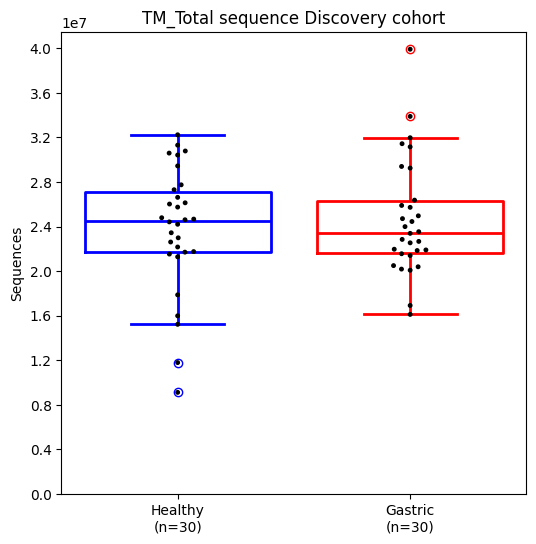

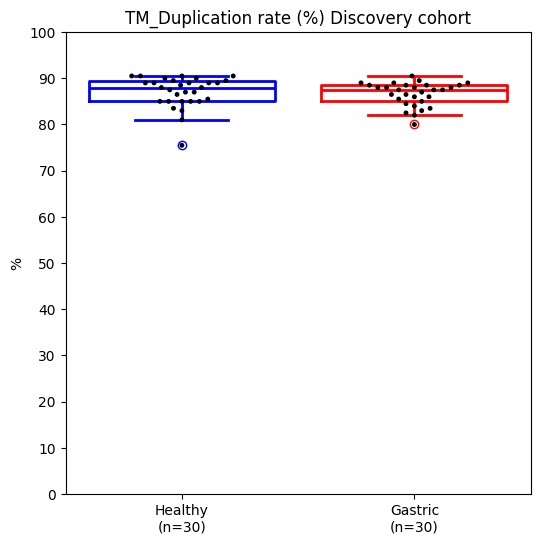

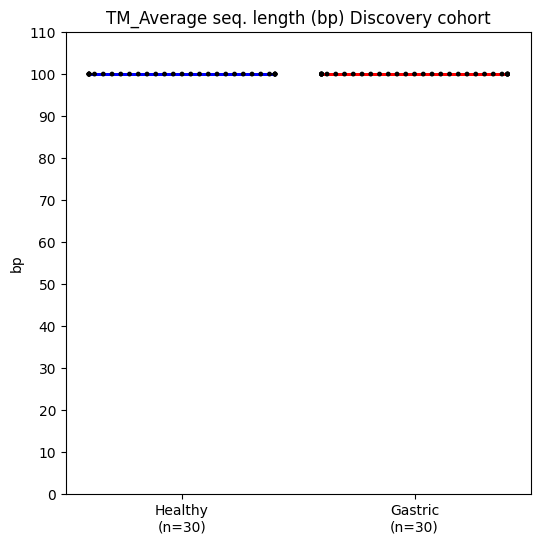

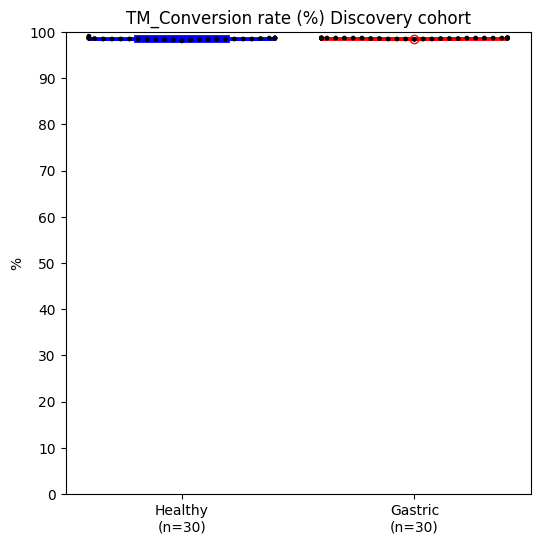

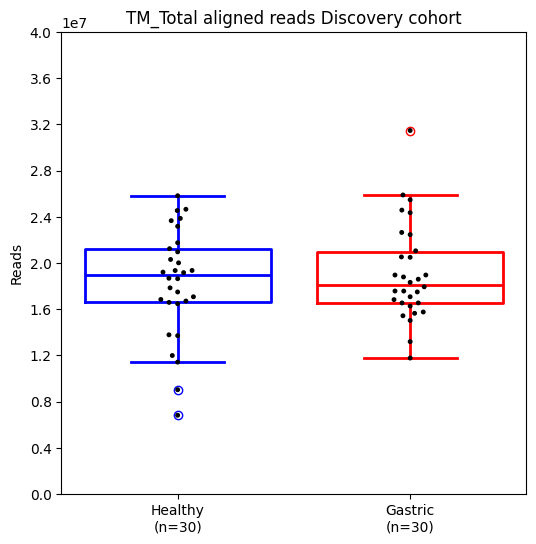

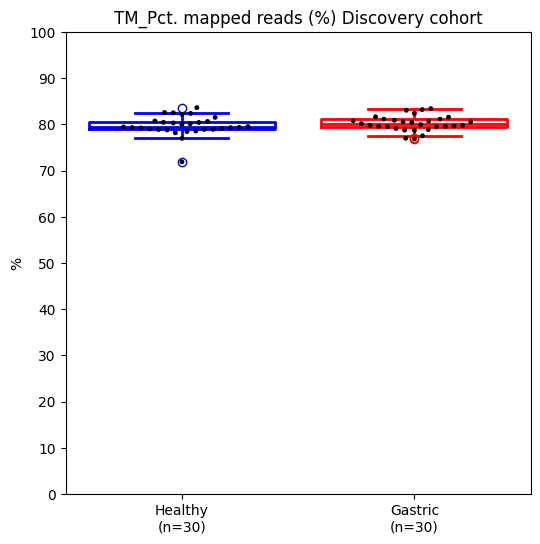

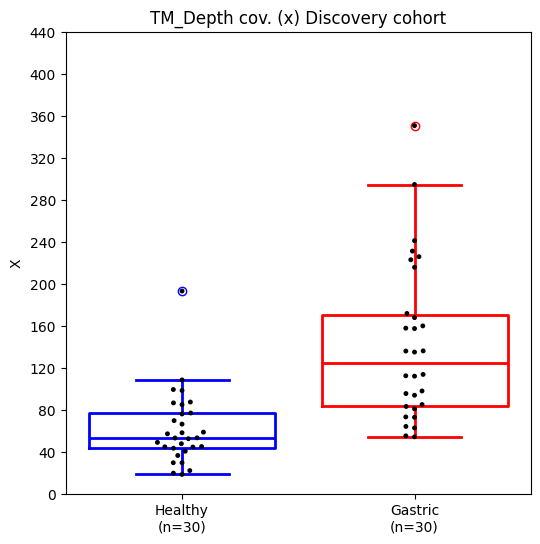

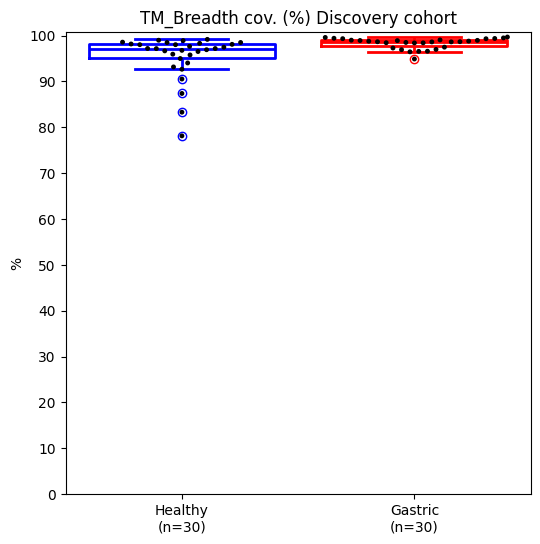

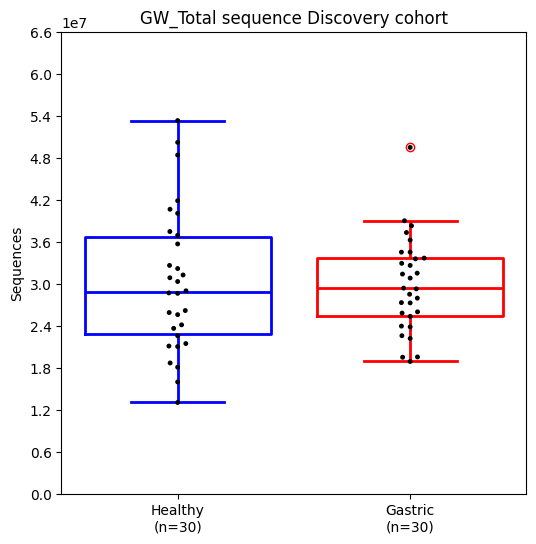

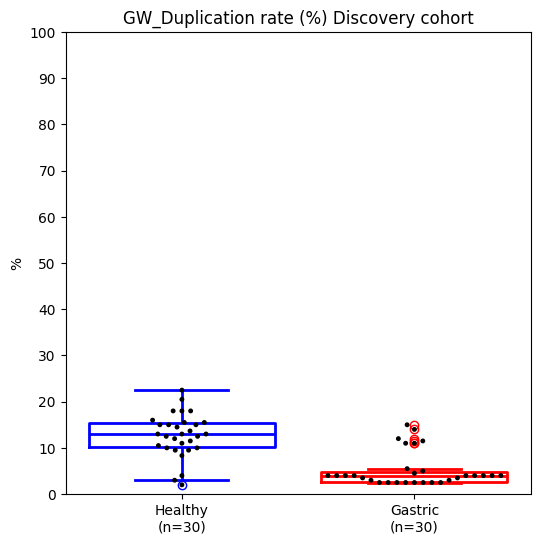

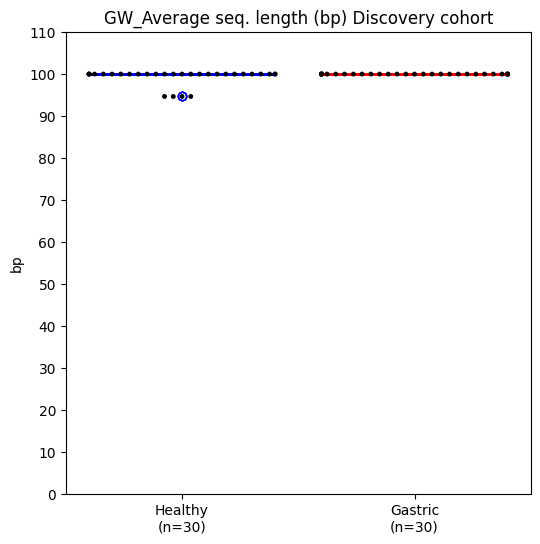

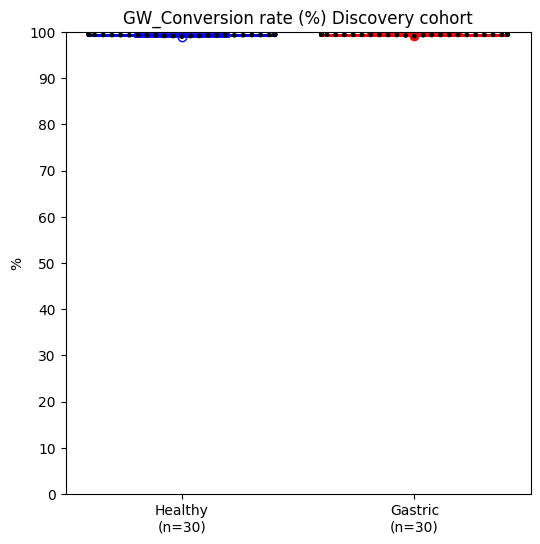

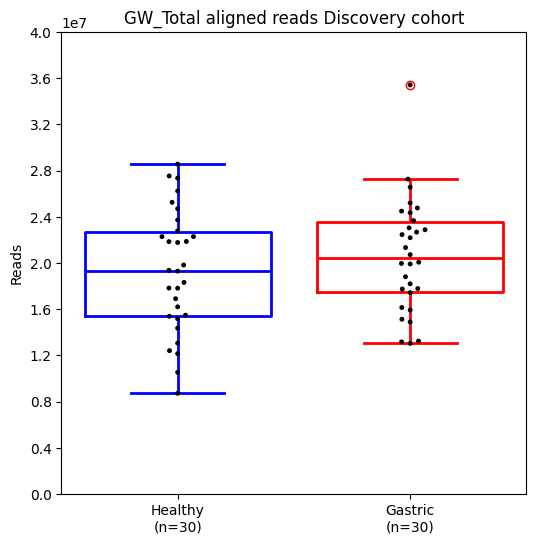

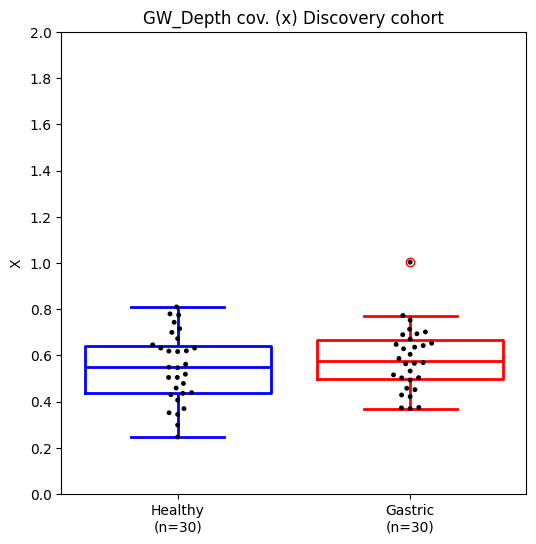

In [114]:
# Các thông số qc seq
# for y in co_horts:
y='Discovery'
df=data_qc[data_qc['Cohort']==y]
# col='Group'
for col in param_seq:
# col='GW_Total sequence'
    if (df[col].dtype!='object') and ('TM' in col or 'GW' in col): 
        if 'sequence' in col:
            ylabel='Sequences'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'rate' in col or 'Pct' in col or 'Breadth' in col:
            ylabel='%'
            stop=110
            step=10
        elif 'aligned' in col:
            ylabel='Reads'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'length' in col:
            ylabel='bp'
            stop=120
            step=10
        elif 'TM_Depth' in col:
            ylabel='X'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'GW_Depth' in col:
            ylabel='X'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1

        plt.figure(figsize=(6,6))
        ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
        ax=sb.boxplot(data=df,y=col,x='Label',palette=['b','r'],fill=False,linewidth=2,order=[0,1])
        ax.set(xlabel=None)
        # sb.swarmplot(data=df,x='Class',y=col,palette=['b','g','orange','r'],marker='o',linewidth=1,order=[0,1,2,3])
        # sb.boxplot(data=df,y=col,x='Class',palette=['white'],order=[0,1,2,3])
        # plt.xlabel()
        plt.yticks(np.arange(0,stop,step))
        labels=[
            'Healthy\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Healthy']))+')',
            'Gastric\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Gastric']))+')',
        ]
        plt.xticks(ticks=[0,1],labels=labels,fontsize=10)
        plt.ylabel(ylabel)
    
        plt.title(col+' '+y+' cohort')

### Plot age

C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2493892408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2493892408.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\XN\AppData\Local\Temp\ipykernel_1260\2493892408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=

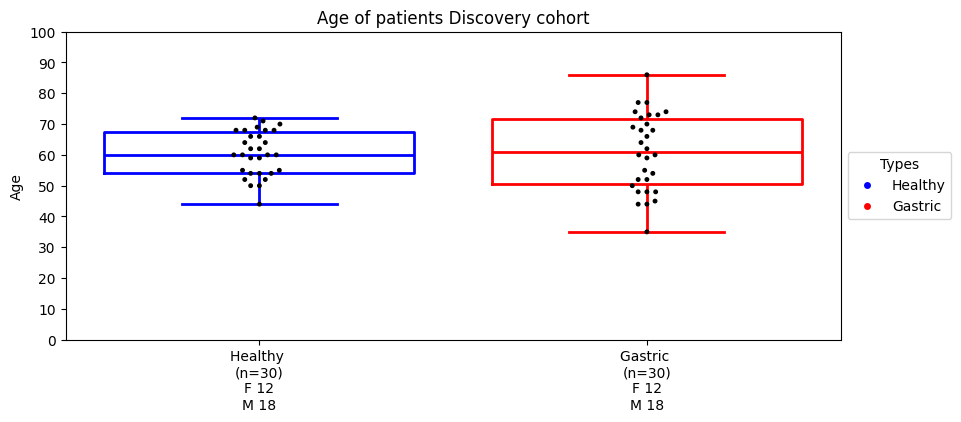

In [115]:
# Plot độ tuổi
for y in ['Discovery']:
# y='Discovery'
    plt.figure(figsize=(10,4))
    sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
    sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['b','r'],order=[0,1],fill=False,linewidth=2)
    plt.yticks(np.arange(0,110,10))
    labels_0='Healthy \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='M')]))
    # labels_1='Gastritis \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    # labels_2='Pre_\ncancerous \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='M')]))
    labels_3='Gastric \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    plt.xticks(ticks=[0,1],labels=[labels_0,labels_3])
    custom_lines = [
                    Line2D([0], [0],marker='o',color='w', markerfacecolor='blue'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='g'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='orange'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r')
                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],title='Types',loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('')
    plt.title('Age of patients '+y+' cohort')

## Load data_all

In [116]:
#data_all=pd.read_csv(exp_id+'_data_all.csv')
data_all=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\Methyl\HNG_TMD_GWMD.csv")
data_all.index=list(data_all['SampleID'])
vector=[]
for s in list(data_all['SampleID']):
    if s in list(data_qc_Discovery['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data_all_Discovery=data_all[vector]
if 'Run_TM' in data_all_Discovery.columns:
    data_all_Discovery.drop(labels='Run_TM',axis=1,inplace=True)
if 'Run_GW' in data_all_Discovery.columns:
    data_all_Discovery.drop(labels='Run_GW',axis=1,inplace=True)
data_all_Discovery

,SampleID,TMD_1,TMD_2,TMD_3,TMD_4,TMD_5,TMD_6,TMD_7,TMD_8,TMD_9,...,Unnamed: 7512,Unnamed: 7513,Unnamed: 7514,Unnamed: 7515,Unnamed: 7516,Unnamed: 7517,Unnamed: 7518,Unnamed: 7519,Unnamed: 7520,Unnamed: 7521
HNGK002,HNGK002,0.947487,0.112098,0.042928,0.096317,0.922474,0.958763,0.971429,0.226926,0.179671,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK003,HNGK003,0.944010,0.128898,0.058059,0.147718,0.930728,0.920000,1.000000,0.297909,0.168750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK004,HNGK004,0.954515,0.096882,0.069846,0.139175,0.965714,0.947761,0.950820,0.360981,0.198098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK005,HNGK005,0.943431,0.082683,0.055310,0.112100,0.934351,0.927757,0.961538,0.124795,0.332714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK006,HNGK006,0.942895,0.140086,0.027823,0.074637,0.942424,0.929134,0.967742,0.210634,0.269311,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK007,HNGK007,0.950935,0.097561,0.032385,0.047170,0.831025,0.936620,1.000000,0.205357,0.093827,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK008,HNGK008,0.980337,0.154362,0.092504,0.053633,0.922559,0.951515,0.945946,0.452128,0.489362,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK009,HNGK009,0.958407,0.120983,0.072761,0.100535,0.952894,0.940000,0.992126,0.228891,0.103524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK010,HNGK010,0.938900,0.133574,0.014614,0.044737,0.940803,0.910615,0.892308,0.265363,0.129902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK011,HNGK011,0.949106,0.070588,0.051302,0.036265,0.955556,0.913706,0.882353,0.371308,0.279514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
list_columns_vlookup=['Cohort','Class','Type','Age','Gender','Run TM','Run GW']

In [118]:
col_start=len(list_columns_vlookup)+1
col_start

8

In [119]:
#Gán label cho data features
for col in list_columns_vlookup:
    lst=[]
    for s in list(data_all_Discovery['SampleID']):
        lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
    data_all_Discovery.insert(loc=1,column=col,value=lst)
data_all_Discovery

,SampleID,Run GW,Run TM,Gender,Age,Type,Class,Cohort,TMD_1,TMD_2,...,Unnamed: 7512,Unnamed: 7513,Unnamed: 7514,Unnamed: 7515,Unnamed: 7516,Unnamed: 7517,Unnamed: 7518,Unnamed: 7519,Unnamed: 7520,Unnamed: 7521
HNGK002,HNGK002,R6110,R6110,F,66,Gastric,4,Discovery,0.947487,0.112098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK003,HNGK003,R6110,R6110,F,72,Gastric,4,Discovery,0.944010,0.128898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK004,HNGK004,R6110,R6110,F,69,Gastric,4,Discovery,0.954515,0.096882,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK005,HNGK005,R6124,R6124,M,48,Gastric,4,Discovery,0.943431,0.082683,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK006,HNGK006,R6124,R6124,F,77,Gastric,4,Discovery,0.942895,0.140086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK007,HNGK007,R6124,R6124,M,55,Gastric,4,Discovery,0.950935,0.097561,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK008,HNGK008,R6178,R6178,M,35,Gastric,4,Discovery,0.980337,0.154362,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK009,HNGK009,R6178,R6178,M,86,Gastric,4,Discovery,0.958407,0.120983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK010,HNGK010,R6178,R6178,F,74,Gastric,4,Discovery,0.938900,0.133574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HNGK011,HNGK011,R6178,R6178,M,73,Gastric,4,Discovery,0.949106,0.070588,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Features

In [120]:
#Chia 6 features
TMD=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('TMD'))],axis=1)
GWMD=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWMD'))],axis=1)
CNA=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('CNA'))],axis=1)
flen=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('flen'))],axis=1)
MOTIF_END=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('MOTIF_END'))],axis=1)
GWFP_long=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_long'))],axis=1)
GWFP_short=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_short'))],axis=1)
GWFP_total=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_total'))],axis=1)
GWFP_ratio=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_ratio'))],axis=1)
# All_features=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('TMD|GWMD|CNA|flen|MOTIF_END|GWFP'))],axis=1)

## DEFINE FEA AND PAIR

In [121]:
features=[
    'TMD',
          'GWMD','CNA','flen','MOTIF_END','GWFP_long','GWFP_short','GWFP_total','GWFP_ratio',
        #   'MOTIF21',
        #   'TM_CNA','TM_RATIO_SHORT_LONG','TM_RATIO_SHORT_TOTAL',
        #   'TM_flen','TM_EM'
        #   'ALL','ALL21',
        #   'ALL21TM',
        #   'CONCAT','CONCAT21',
        #   'CONCAT21TM'
          ]
features

['TMD',
 'GWMD',
 'CNA',
 'flen',
 'MOTIF_END',
 'GWFP_long',
 'GWFP_short',
 'GWFP_total',
 'GWFP_ratio']

## Group adjusted p-value

In [122]:
TM_id=[str(n) for n in np.arange(1,375,1)]+[str(n) for n in np.arange(376,452,1)]
groups_padj={}
for f in features:
    if f == 'TM_EM':
        groups_padj[f]=['TM_EM_'+i+'_' for i in TM_id]
    elif f == 'TM_flen':
        groups_padj[f]=['TM_flen_'+i+'_' for i in TM_id]
    # elif f == 'Region_depth':
    #     groups_padj[f]=['TMD']
    elif f == 'TM_flen_entropy':
        groups_padj[f]=['TM_flen']
    elif f == 'TM_EM_entropy':
        groups_padj[f]=['TM_EM']    
    else:
        groups_padj[f]=[f]

## PAIR

In [123]:
PAIR=[
    # 'Non_cancer vs Cancer',
    # 'Non_cancer vs Gastric',
    # 'Healthy vs Lesion',
    # 'Gastritis vs Cancer',
    # 'Healthy vs Gastritis',
    # 'Healthy vs Precancerous',
    'Healthy vs Gastric',
    # 'Gastritis vs Precancerous',
    # 'Gastritis vs Gastric',
    # 'Precancerous vs Gastric',
    # 'Non_Gastric vs Gastric'
    #   'Healthy vs Colorectal_cancer'
      ]

## Fea

In [124]:
fea={
    'TMD':TMD,
    'GWMD':GWMD,
    'CNA':CNA,
    'flen':flen,
    'MOTIF_END':MOTIF_END,
    'GWFP_long':GWFP_long,
    'GWFP_short':GWFP_short,
    'GWFP_total':GWFP_total,
    'GWFP_ratio':GWFP_ratio,
    # 'MOTIF21':MOTIF21
    }

# ANALYSIS

## Statistic

In [ ]:
#!!!! Chỉ chạy 1 lần xong khóa code lại 
stats_fea={}
for f in features:
    # if f not in ['CONCAT','CONCAT21','CONCAT21TM']:
        stats_fea[f]=STATS_features(fea[f],PAIR,col_start=col_start,groups_PADJ=groups_padj[f])

In [ ]:
Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[df['PADJ of '+p]<0.05])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,TMD,GWMD,CNA,flen,MOTIF_END,GWFP_long,GWFP_short,GWFP_total,GWFP_ratio
0,Healthy vs Gastric,0,269,277,146,143,116,186,118,588


# TMD

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


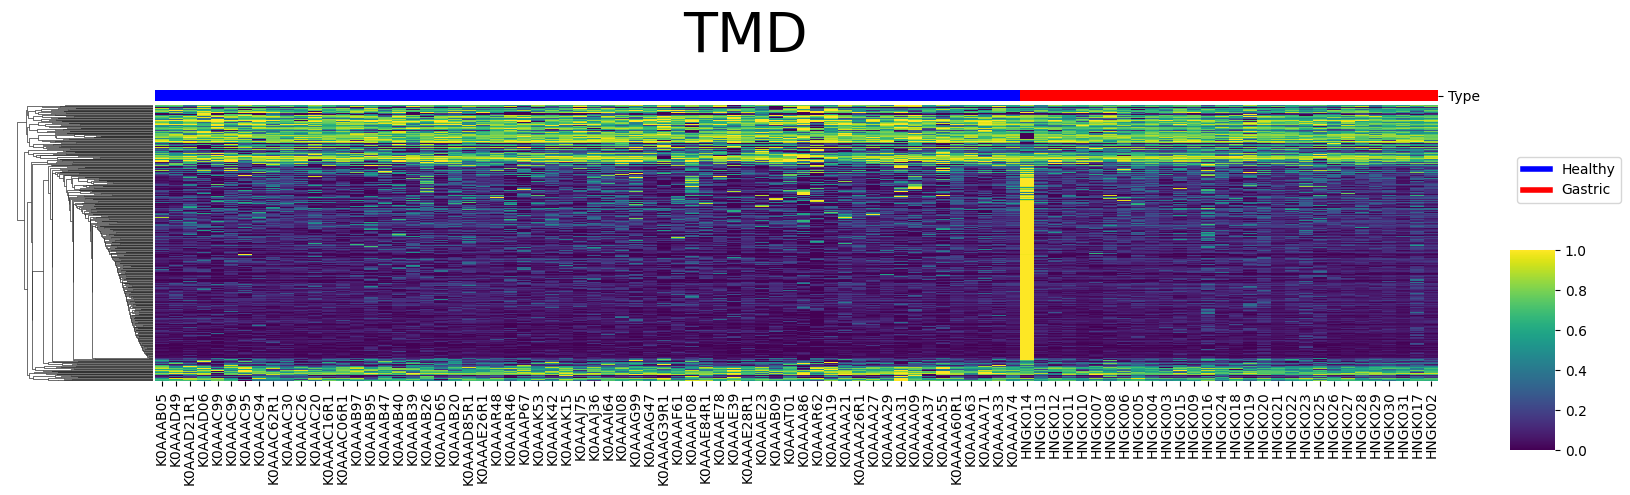

In [ ]:
heatmapfea('TMD')

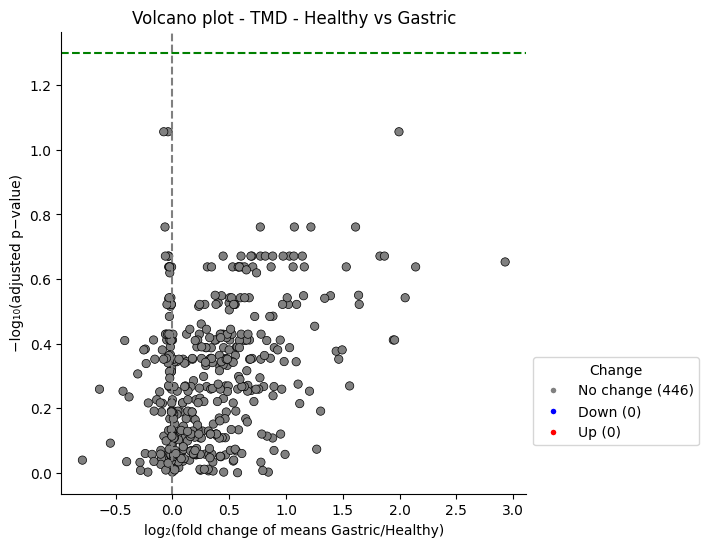

In [ ]:
volcanofea('TMD',pair=['Healthy vs Gastric'])

# GWMD

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


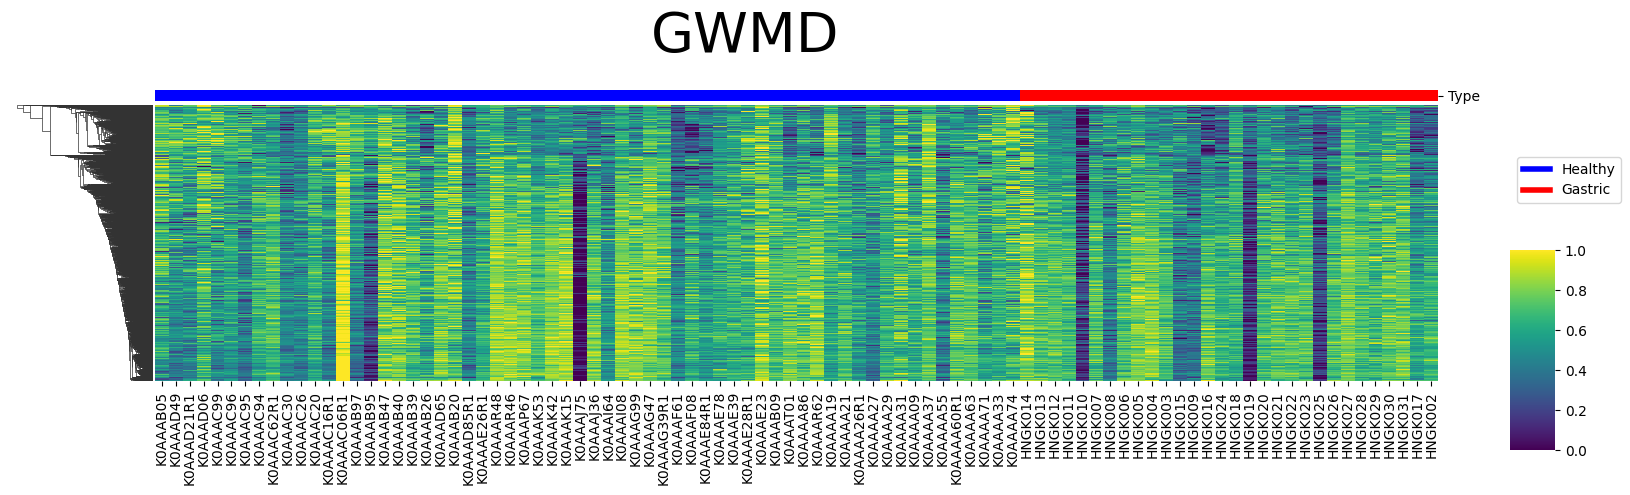

In [ ]:
heatmapfea('GWMD')

In [ ]:
M=[]
S=[]
for s in GWMD['SampleID']:
    m=np.mean(list(GWMD[GWMD['SampleID']==s].iloc[:,col_start:].T[s]))
    M+=[m]
    S+=[s]
resu=pd.DataFrame({'SampleID':S,'Mean':M})
resu

,SampleID,Mean
0,HNGK002,0.807896
1,HNGK003,0.815808
2,HNGK004,0.825831
3,HNGK005,0.826292
4,HNGK006,0.816515
...,...,...
87,K0AAAP67,0.829646
88,K0AAAR46,0.827362
89,K0AAAR48,0.834489
90,K0AAAR62,0.823823


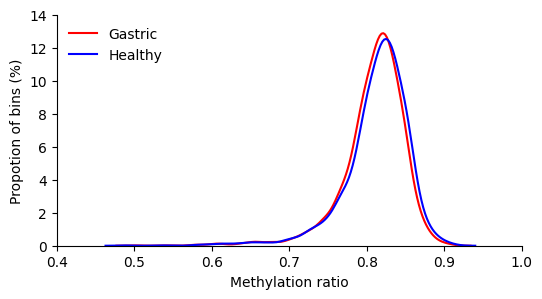

In [ ]:
G={
'Mean of Healthy':'b',
#    'Mean of Gastritis':'b',
#    'Mean of Precancerous':'goldenrod',
   'Mean of Gastric':'r'}
df=stats_fea['GWMD'][list(G.keys())]
df=pd.melt(df)

# plt.figure(figsize=(12/1.6, 3/1.6))
plt.figure(figsize=(6,3))
sb.kdeplot(data=df, x='value', hue='variable', fill=False, common_norm=False, palette=G)
 
# Set labels and title
plt.xlim(0.4,1)
plt.xlabel('Methylation ratio')
plt.ylabel('Propotion of bins (%)')
plt.yticks(np.arange(0,16,2))
# plt.title('Density Plot GWMD')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Display the legend
plt.legend(loc='upper left',frameon=False, labels=['Gastric', 'Healthy'])
# plt.savefig('.\Poster\GWMD_distribution.png', dpi=600, bbox_inches='tight')
# Show the plot


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# Định nghĩa màu nhóm
G = {
    'Mean of Healthy': 'b',
    'Mean of Gastric': 'r'
}

# Chuẩn bị dữ liệu
df = stats_fea['GWMD'][list(G.keys())]
df = pd.melt(df, var_name='Group', value_name='Methylation ratio')

# ✅ Tính giá trị trung bình và 95% CI mỗi nhóm
summary_stats = df.groupby('Group')['Methylation ratio'].agg(['mean', 'std', 'count']).reset_index()
summary_stats['95% CI lower'] = summary_stats['mean'] - 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])
summary_stats['95% CI upper'] = summary_stats['mean'] + 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])
print("📊 Summary Statistics with 95% CI:")
print(summary_stats)

# ✅ Kiểm định sự khác biệt giữa các nhóm (Mann-Whitney U test và t-test)
healthy = df[df['Group'] == 'Mean of Healthy']['Methylation ratio']
gastric = df[df['Group'] == 'Mean of Gastric']['Methylation ratio']

u_stat, p_mwu = mannwhitneyu(healthy, gastric, alternative='two-sided')
t_stat, p_ttest = ttest_ind(healthy, gastric)

print(f"\n📌 Mann-Whitney U test: U={u_stat:.2f}, p={p_mwu:.4f}")
print(f"📌 T-test: t={t_stat:.2f}, p={p_ttest:.4f}")

# ✅ Biện luận kết quả
if p_mwu < 0.05:
    print("👉 Có sự khác biệt có ý nghĩa thống kê giữa nhóm Healthy và Gastric (p < 0.05).")
else:
    print("👉 Không phát hiện sự khác biệt có ý nghĩa giữa nhóm Healthy và Gastric (p ≥ 0.05).")

# ✅ Vẽ biểu đồ KDE
plt.figure(figsize=(6, 3))
sb.kdeplot(data=df, x='Methylation ratio', hue='Group', fill=False, common_norm=False, palette=G)

# Set labels and title
plt.xlim(0.4, 1)
plt.xlabel('Methylation ratio')
plt.ylabel('Proportion of bins (%)')
plt.yticks(np.arange(0, 16, 2))

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Display the legend
plt.legend(loc='upper left', frameon=False, labels=['Gastric', 'Healthy'])

plt.tight_layout()
plt.show() 

In [ ]:
def vectorcolor(p,f):
    data_split=stats_fea[f]
    # data_concatenate=stats_fea['All_features']
    col_PADJ='PADJ of '+p
    col_L2FC='Log2FC of '+p
    cols=[]
    for i in list(data_split.iloc[:,0]):
        PADJ_split=data_split[data_split[data_split.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
        # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]

        L2FC_split=data_split[data_split[data_split.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]

        if L2FC_split <0 and PADJ_split<=0.05:
            cols.append('b')
        elif L2FC_split >=0 and PADJ_split<=0.05:
            cols.append('red')
        elif PADJ_split>0.05:
            cols.append('gray')
    return cols

In [ ]:
#Tạo position cho chromosome
Chromosome=[]
for i in range(len(stats_fea['GWMD'])):
    chromosome=int(stats_fea['GWMD']['FEATURES'].iloc[i].split("chr")[1].split("_")[0])
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,230,230,57
2,242,472,351
3,196,668,570
4,190,858,763
5,179,1037,947
6,170,1207,1122
7,158,1365,1286
8,145,1510,1437
9,125,1635,1572


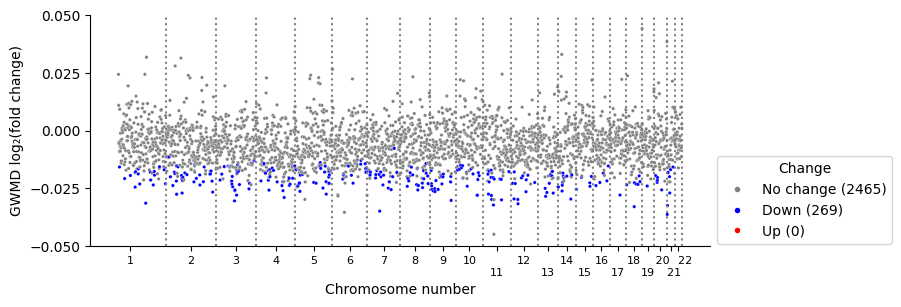

In [ ]:
f='GWMD'
custom_lines = [Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=5),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=5),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)
    # plt.figure(figsize=(8/1.1, 3/1.5))
    plt.figure(figsize=(8,3))
    xlabels=['1','2','3','4','5','6','7','8','9','10','\n11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','    22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':')

    sb.scatterplot(x=x,y=y,c=cols,s=6)
    lst_name_show=["CNA_10:135000001-135534747"]
    region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.05,0.075,0.025))
    plt.xlabel('Chromosome number')
    plt.ylabel('GWMD '+u'log\u2082(fold change)')
    # plt.title(f+'_'+p)
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    
    se_cols=pd.Series(cols)
    count=se_cols.value_counts()
    lst=[]
    for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
        lst+=[i+' ('+str(count.get(j, 0))+')']
    plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(1.2, 0.5),frameon=False)
    # plt.legend(custom_lines,['Hypermethylated','Hypomethylated','No change'],loc='center left', bbox_to_anchor=(1, 0.5),title='Group',frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Poster\GWMD_bins.png', dpi=600, bbox_inches='tight')

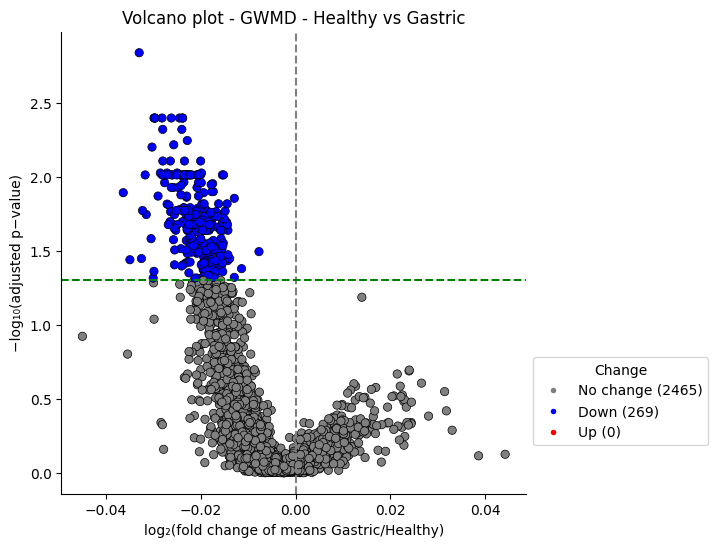

In [ ]:
volcanofea('GWMD',['Healthy vs Gastric'],show_region=False)